In [1]:
import pandas as pd
import requests
import torch
from dataclasses import asdict
from datasets import load_dataset
from peft import PeftModel, PeftConfig, AutoPeftModelForCausalLM, get_model_status, \
get_layer_status, prepare_model_for_kbit_training, LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from trl import SFTTrainer, SFTConfig

In [2]:
from peft import get_model_status, get_layer_status


## Deploying in a Nutshell

Most people do not have GPUs in their
computers, and end-users won’t have Python, PyTorch, and Hugging Face installed either.

### one such example is open neural network exchange 

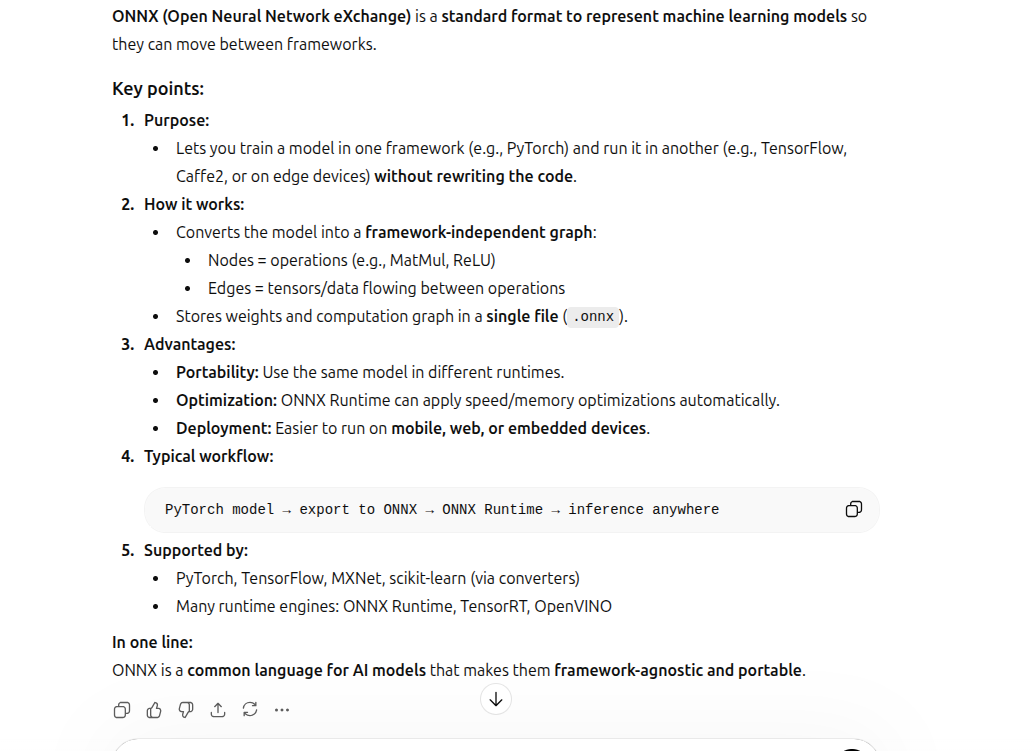

ONNX (Open Neural Network Exchange)[25] was an early effort to create a unified format for
deploying models across various frameworks and platforms.

## llama.cpp

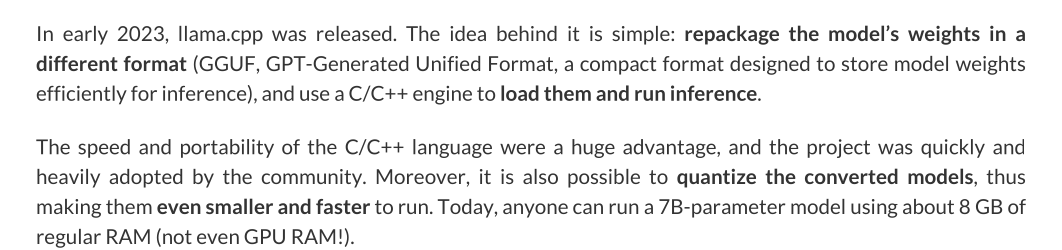

While the base models are easily available in the GGUF format, and at different levels of quantization, serving
our own fine-tuned models requires a bit of extra work. Deploying them locally requires converting and
quantizing models and adapters ourselves.

Once converted, these models can be served—that is, made available—either through a web interface or a
REST API using llama.cpp itself or Ollama, one of the most popular tools for using LLMs locally.|

## Loading Models and Adapters

In [6]:
import torch
from peft import PeftModel, PeftConfig, AutoPeftModelForCausalLM, get_model_status, get_layer_status
from transformers import AutoModelForCausalLM, AutoTokenizer
 
repo_or_folder = "yoda-adapter"  

## — read adapter config

PeftConfig tells us which base model was used during training

This is the safest way to find the base model name — don't hard-code it.


In [10]:
from peft import PeftConfig

repo_or_folder = './yoda-adapter'  # your local folder
config = PeftConfig.from_pretrained(repo_or_folder, local_files_only=True)

ValueError: Can't find 'adapter_config.json' at './yoda-adapter'